In [ ]:
print("h")

h


Visualizing: ocr_surgical_crop_0.png


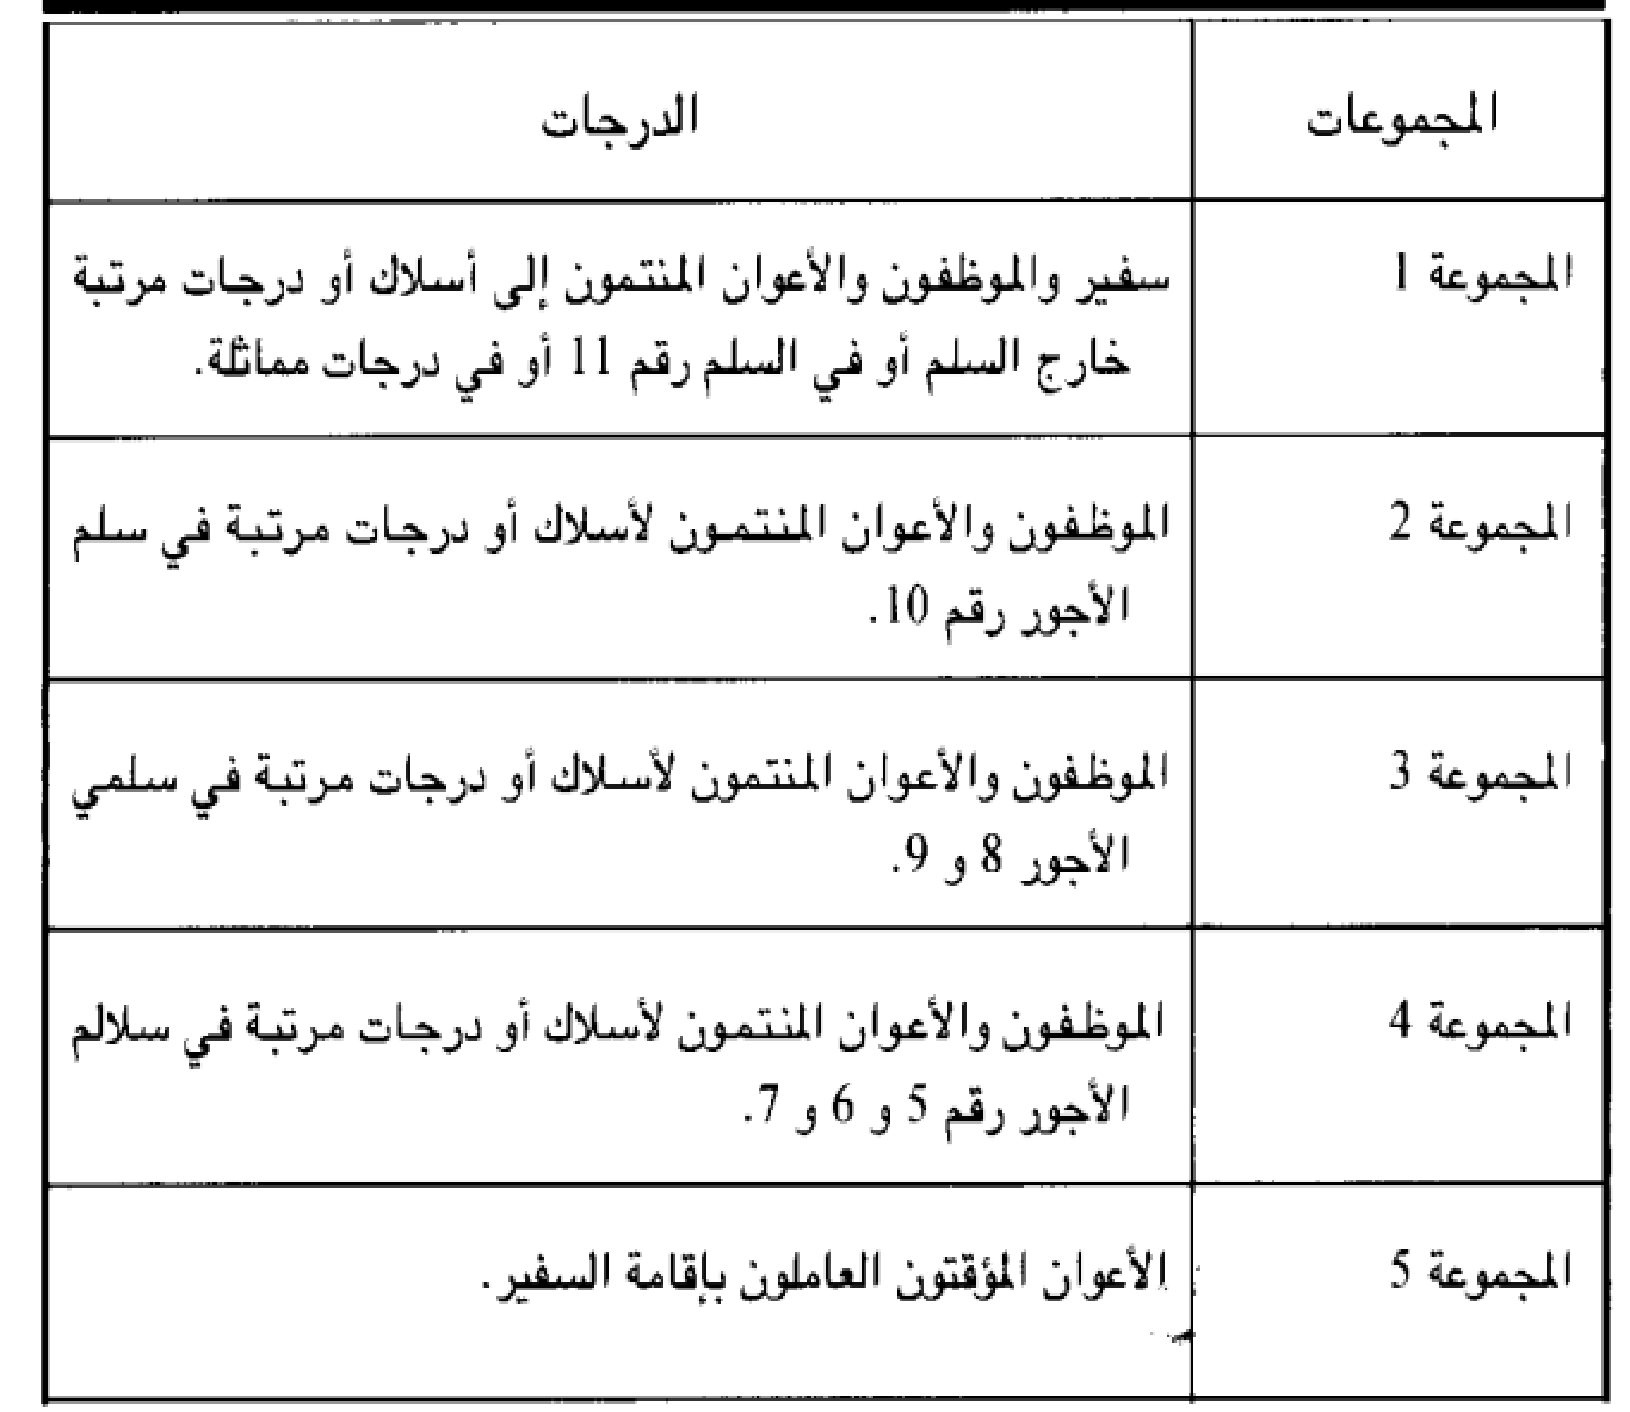


Calling Ollama deepseek-ocr... (Streaming)

--- 1. RAW OLLAMA OUTPUT ---
<|ref|>table<|/ref|><|det|>[[24, 11, 987, 977]]<|/det|>
<table><tr><td>الدرجات</td><td>المجموعات</td></tr><tr><td>سفير والموظفون والأعوان المنتمون إلى أسلاك أو درجات مرتبة خارج السلم أو في السلم رقم 11 أو في درجات مماثلة.</td><td>المجموعة 1</td></tr><tr><td>الموظفون والأعوان المنتمون لأسلاك أو درجات مرتبة في سلم الأجور رقم 10.</td><td>المجموعة 2</td></tr><tr><td>الموظفون والأعوان المنتمون لأسلاك أو درجات مرتبة في سلمي الأجور 8 و 9.</td><td>المجموعة 3</td></tr><tr><td>الموظفون والأعوان المنتمون لأسلاك أو درجات مرتبة في سلامي الأجور رقم 5 و 6 و 7.</td><td>المجموعة 4</td></tr><tr><td>الأعوان المؤقتون العاملون بإقامة السفير.</td><td>المجموعة 5</td></tr></table>

--- 2. CLEANED OUTPUT ---
<table><tr><td>الدرجات</td><td>المجموعات</td></tr><tr><td>سفير والموظفون والأعوان المنتمون إلى أسلاك أو درجات مرتبة خارج السلم أو في السلم رقم 11 أو في درجات مماثلة.</td><td>المجموعة 1</td></tr><tr><td>الموظفون والأعوان المنتمون لأسل

In [ ]:
import ollama
import re
from IPython.display import Image, display

# Show the image we are testing
image_path = "ocr_surgical_crop_0.png"
print("Visualizing:", image_path)
display(Image(filename=image_path))

# 1. Load image bytes
with open(image_path, "rb") as f:
    img_bytes = f.read()

print("\nCalling Ollama deepseek-ocr... (Streaming)")
stream = ollama.generate(
    model="deepseek-ocr:latest",
    prompt="<|grounding|>Convert the document to text.",
    images=[img_bytes],
    stream=True,
    options={"temperature": 0, "repeat_penalty": 1.5},
)

print("\n--- 1. RAW OLLAMA OUTPUT ---")
raw_text = ""
for chunk in stream:
    text_chunk = chunk.get("response", "")
    print(text_chunk, end="", flush=True)
    raw_text += text_chunk
print()


# 2. Clean grounding tags logic
def clean_deepseek_output(text: str) -> str:
    text = re.sub(r"<\|ref\|>.*?<\|/ref\|>", "", text)
    text = re.sub(r"<\|det\|>.*?<\|/det\|>", "", text)
    text = re.sub(r"<\|.*?\|>", "", text)
    return text.strip()


cleaned_text = clean_deepseek_output(raw_text)
print("\n--- 2. CLEANED OUTPUT ---")
print(cleaned_text)

# 3. Table HTML to RAG logic (imported directly from the library)
try:
    from pdf2text_arabic._tables import html_to_rag_text

    rag_text = html_to_rag_text(cleaned_text)
    print("\n--- 3. RAG CONVERTED OUTPUT ---")
    print(rag_text)
except Exception as e:
    print("\n--- RAG CONVERSION FAILED ---")
    print(e)